# Exploratory Data Analysis

This notebook explores the Online Retail II transactional dataset to understand distributions, outliers, missing values, and customer purchasing patterns before building customer segments via cluster analysis.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Helper Classes

In [2]:
class ExploratoryDataAnalysis:
    def __init__(self, str_uri, str_dirname_output):
        self.str_uri = str_uri
        self.str_dirname_output = str_dirname_output

    def import_data(self):
        df = pd.read_parquet(self.str_uri)
        df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')
        df.sort_values(by='invoicedate', ascending=True, inplace=True)
        self.df = df

    def get_df_info(self):
        int_nrows, int_ncols = self.df.shape
        dtm_min = self.df['invoicedate'].min()
        dtm_max = self.df['invoicedate'].max()
        flt_nan = self.df.isna().values.mean()
        print(f'Rows: {int_nrows:,}')
        print(f'Columns: {int_ncols}')
        print(f'Min Date: {dtm_min}')
        print(f'Max Date: {dtm_max}')
        print(f'Proportion NaN: {flt_nan:0.4f}')
        print(f'\nUnique Invoices: {self.df["invoice"].nunique():,}')
        print(f'Unique Customers: {self.df["customer_id"].nunique():,}')
        print(f'Unique Products: {self.df["stockcode"].nunique():,}')
        print(f'Unique Countries: {self.df["country"].nunique():,}')
        self.int_nrows = int_nrows
        self.int_ncols = int_ncols

    def descriptives(self):
        list_cols = ['quantity', 'price']
        list_dict_row = []
        for col in tqdm(list_cols):
            dict_row = {
                'col': col,
                'nan': self.df[col].isnull().mean(),
                'nunique': self.df[col].nunique(),
                'min': self.df[col].min(),
                'max': self.df[col].max(),
                'mean': self.df[col].mean(),
                'std': self.df[col].std(),
                'mdn': self.df[col].median(),
                'p01': self.df[col].quantile(0.01),
                'p99': self.df[col].quantile(0.99),
            }
            list_dict_row.append(dict_row)
        self.df_descriptives = pd.DataFrame(list_dict_row)

    def plot_missing_values(self):
        ser_missing = self.df.isnull().mean().sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.set_title('Missing Value Proportion by Column')
        ax.set_xlabel('Proportion Missing')
        ax.barh(ser_missing.index, ser_missing.values, color='tab:blue')
        for i, (col, val) in enumerate(ser_missing.items()):
            if val > 0:
                ax.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/missing_values.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_transactions_over_time(self):
        df_tmp = self.df.copy()
        df_tmp['invoice_month'] = df_tmp['invoicedate'].dt.to_period('M').dt.to_timestamp()
        df_tmp['revenue'] = df_tmp['quantity'] * df_tmp['price']
        df_pivot = df_tmp.groupby(by='invoice_month', as_index=False).agg(
            n_transactions=('invoice', 'nunique'),
            total_revenue=('revenue', 'sum'),
        )
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.set_title('Transaction Volume and Revenue by Month')
        ax.set_xlabel('Month')
        ax.set_ylabel('N Transactions', color='tab:blue')
        ax.plot(df_pivot['invoice_month'], df_pivot['n_transactions'], color='tab:blue', marker='o', markersize=4)
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax2 = ax.twinx()
        ax2.bar(df_pivot['invoice_month'], df_pivot['total_revenue'], alpha=0.3, color='tab:red', width=20)
        ax2.set_ylabel('Total Revenue', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        fig.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/transactions_over_time.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_top_countries(self, int_top_n=15):
        df_tmp = self.df.copy()
        df_tmp['revenue'] = df_tmp['quantity'] * df_tmp['price']
        df_country = df_tmp.groupby(by='country', as_index=False).agg(
            n_customers=('customer_id', 'nunique'),
            n_transactions=('invoice', 'nunique'),
            total_revenue=('revenue', 'sum'),
        )
        df_country.sort_values(by='total_revenue', ascending=True, inplace=True)
        df_country = df_country.tail(int_top_n)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f'Top {int_top_n} Countries', fontsize=16, y=1.02)
        axes[0].barh(df_country['country'], df_country['n_customers'], color='tab:blue')
        axes[0].set_title('N Customers')
        axes[1].barh(df_country['country'], df_country['n_transactions'], color='tab:green')
        axes[1].set_title('N Transactions')
        axes[2].barh(df_country['country'], df_country['total_revenue'], color='tab:red')
        axes[2].set_title('Total Revenue')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/top_countries.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_distributions(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Distributions (Clipped at 1st/99th Percentiles)', fontsize=14, y=1.02)
        for idx, col in enumerate(['quantity', 'price']):
            ax = axes[idx]
            p01 = self.df[col].quantile(0.01)
            p99 = self.df[col].quantile(0.99)
            ser_clipped = self.df[col].clip(lower=p01, upper=p99)
            ax.hist(ser_clipped, bins=50, color='tab:blue', alpha=0.7, edgecolor='black', linewidth=0.3)
            ax.axvline(ser_clipped.median(), color='tab:red', linestyle='--', label=f'Median: {ser_clipped.median():.1f}')
            ax.set_title(col)
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            ax.legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/distributions.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_cancellation_analysis(self):
        df_tmp = self.df.copy()
        df_tmp['is_cancellation'] = df_tmp['invoice'].astype(str).str.startswith('C')
        flt_cancel_rate = df_tmp['is_cancellation'].mean()
        # cancellation rate by month
        df_tmp['invoice_month'] = df_tmp['invoicedate'].dt.to_period('M').dt.to_timestamp()
        df_pivot = df_tmp.groupby(by='invoice_month', as_index=False).agg(
            cancel_rate=('is_cancellation', 'mean'),
            n_rows=('is_cancellation', 'count'),
        )
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.set_title(f'Cancellation Rate by Month (Overall: {flt_cancel_rate:.2%})')
        ax.set_xlabel('Month')
        ax.set_ylabel('Cancellation Rate')
        ax.plot(df_pivot['invoice_month'], df_pivot['cancel_rate'], color='tab:red', marker='o', markersize=4)
        ax.axhline(y=flt_cancel_rate, color='gray', linestyle='--', alpha=0.5)
        fig.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/cancellation_rate.png', bbox_inches='tight', dpi=150)
        plt.show()

    def preview_rfm(self):
        df_tmp = self.df.copy()
        # exclude cancellations for RFM preview
        df_tmp = df_tmp[~df_tmp['invoice'].astype(str).str.startswith('C')].copy()
        df_tmp = df_tmp[df_tmp['customer_id'].notna()].copy()
        df_tmp['revenue'] = df_tmp['quantity'] * df_tmp['price']
        dtm_reference = df_tmp['invoicedate'].max() + pd.Timedelta(days=1)
        df_rfm = df_tmp.groupby(by='customer_id', as_index=False).agg(
            recency=('invoicedate', lambda x: (dtm_reference - x.max()).days),
            frequency=('invoice', 'nunique'),
            monetary=('revenue', 'sum'),
        )
        self.df_rfm_preview = df_rfm
        # plot RFM distributions
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('RFM Preview Distributions', fontsize=14, y=1.02)
        for idx, col in enumerate(['recency', 'frequency', 'monetary']):
            ax = axes[idx]
            p99 = df_rfm[col].quantile(0.99)
            ser_clipped = df_rfm[col].clip(upper=p99)
            ax.hist(ser_clipped, bins=50, color='tab:blue', alpha=0.7, edgecolor='black', linewidth=0.3)
            ax.axvline(ser_clipped.median(), color='tab:red', linestyle='--', label=f'Median: {df_rfm[col].median():.1f}')
            ax.set_title(f'{col.capitalize()} (N={len(df_rfm):,})')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            ax.legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/rfm_preview.png', bbox_inches='tight', dpi=150)
        plt.show()

    def plot_correlation_heatmap(self):
        df_rfm = self.df_rfm_preview.copy()
        df_corr = df_rfm[['recency', 'frequency', 'monetary']].corr()
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.set_title('RFM Correlation Heatmap')
        sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1, square=True, ax=ax,
                    linewidths=0.5, cbar_kws={'shrink': 0.8})
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/correlation_heatmap.png', bbox_inches='tight', dpi=150)
        plt.show()

## Constants

In [3]:
str_bucket = 'cluster-analysis-demo'
print(f'Bucket: {str_bucket}')

str_task = '01_eda'
print(f'Task: {str_task}')

str_dirname_output = './output'

# data uri
str_uri = f's3://{str_bucket}/00_data_collection/data.parquet'

Bucket: cluster-analysis-demo
Task: 01_eda


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Initialize EDA Class

In [5]:
cls_eda = ExploratoryDataAnalysis(
    str_uri=str_uri,
    str_dirname_output=str_dirname_output,
)

## Import Data

In [6]:
cls_eda.import_data()
cls_eda.df

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525423,538171,20771,CHRYSANTHEMUM JOURNAL,1,2010-12-09 20:01:00,2.55,17530.0,United Kingdom
525424,538171,21882,SKULLS TAPE,5,2010-12-09 20:01:00,0.65,17530.0,United Kingdom
525425,538171,21879,HEARTS GIFT TAPE,5,2010-12-09 20:01:00,0.65,17530.0,United Kingdom
525411,538171,20777,CHRYSANTHEMUM NOTEBOOK,2,2010-12-09 20:01:00,1.65,17530.0,United Kingdom


## Dataset Summary

In [7]:
cls_eda.get_df_info()

Rows: 525,461
Columns: 8
Min Date: 2009-12-01 07:45:00
Max Date: 2010-12-09 20:01:00
Proportion NaN: 0.0257

Unique Invoices: 28,816
Unique Customers: 4,383
Unique Products: 4,632
Unique Countries: 40


## Descriptive Statistics

In [8]:
cls_eda.descriptives()
cls_eda.df_descriptives

100%|██████████| 2/2 [00:00<00:00, 28.55it/s]


,col,nan,nunique,min,max,mean,std,mdn,p01,p99
0,quantity,0.0,825,-9600.00,19152.00,10.337667,107.424110,3.0,-3.00,120.00
1,price,0.0,1606,-53594.36,25111.09,4.688834,146.126914,2.1,0.21,19.95


## Missing Values

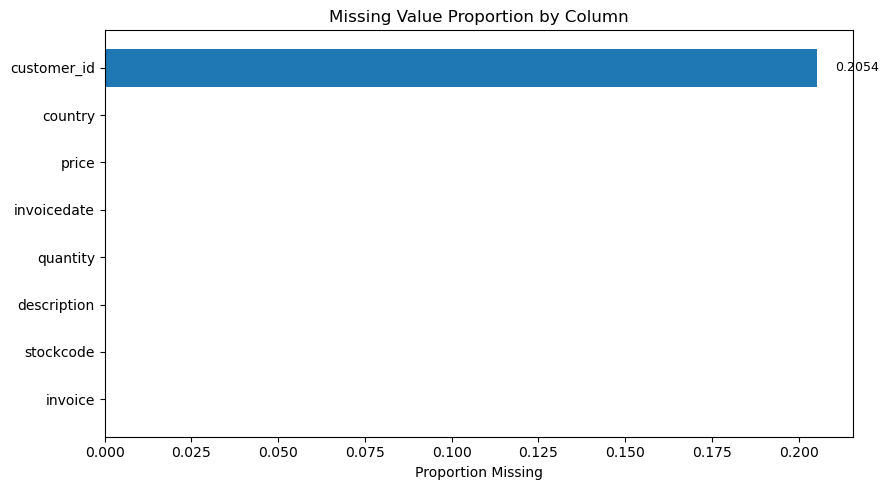

In [9]:
cls_eda.plot_missing_values()

## Distributions

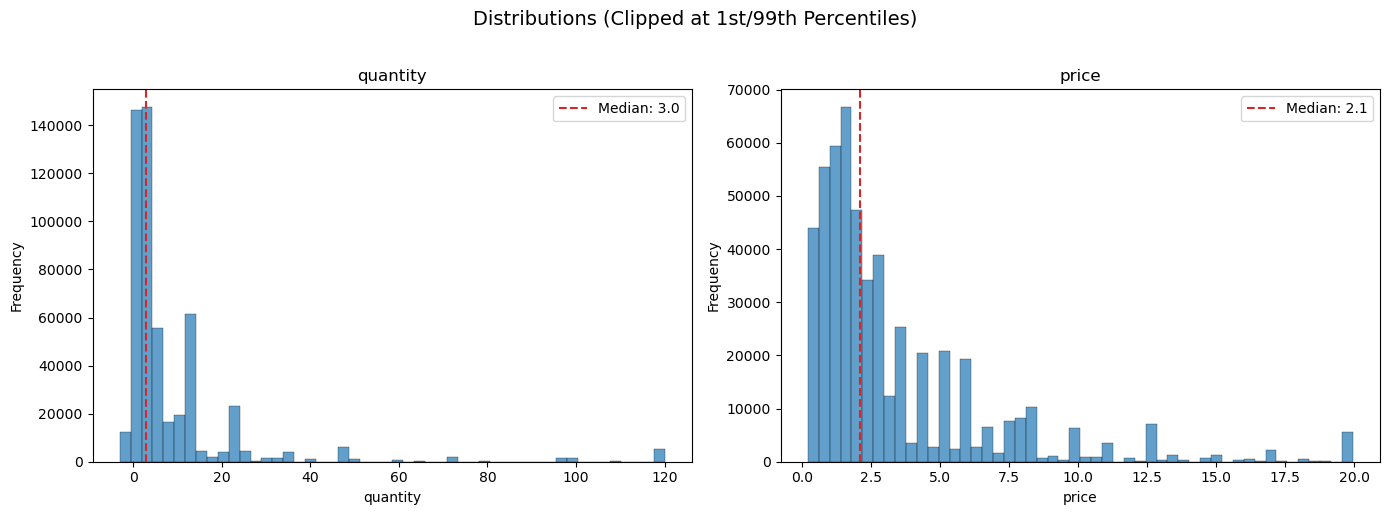

In [10]:
cls_eda.plot_distributions()

## Transaction Volume and Revenue Over Time

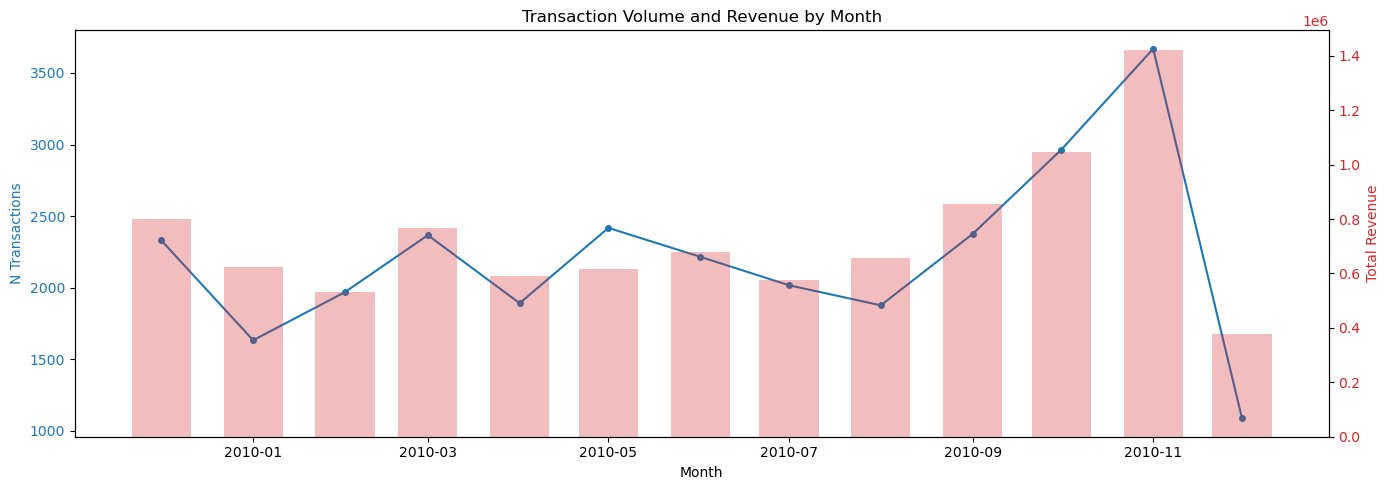

In [11]:
cls_eda.plot_transactions_over_time()

## Top Countries

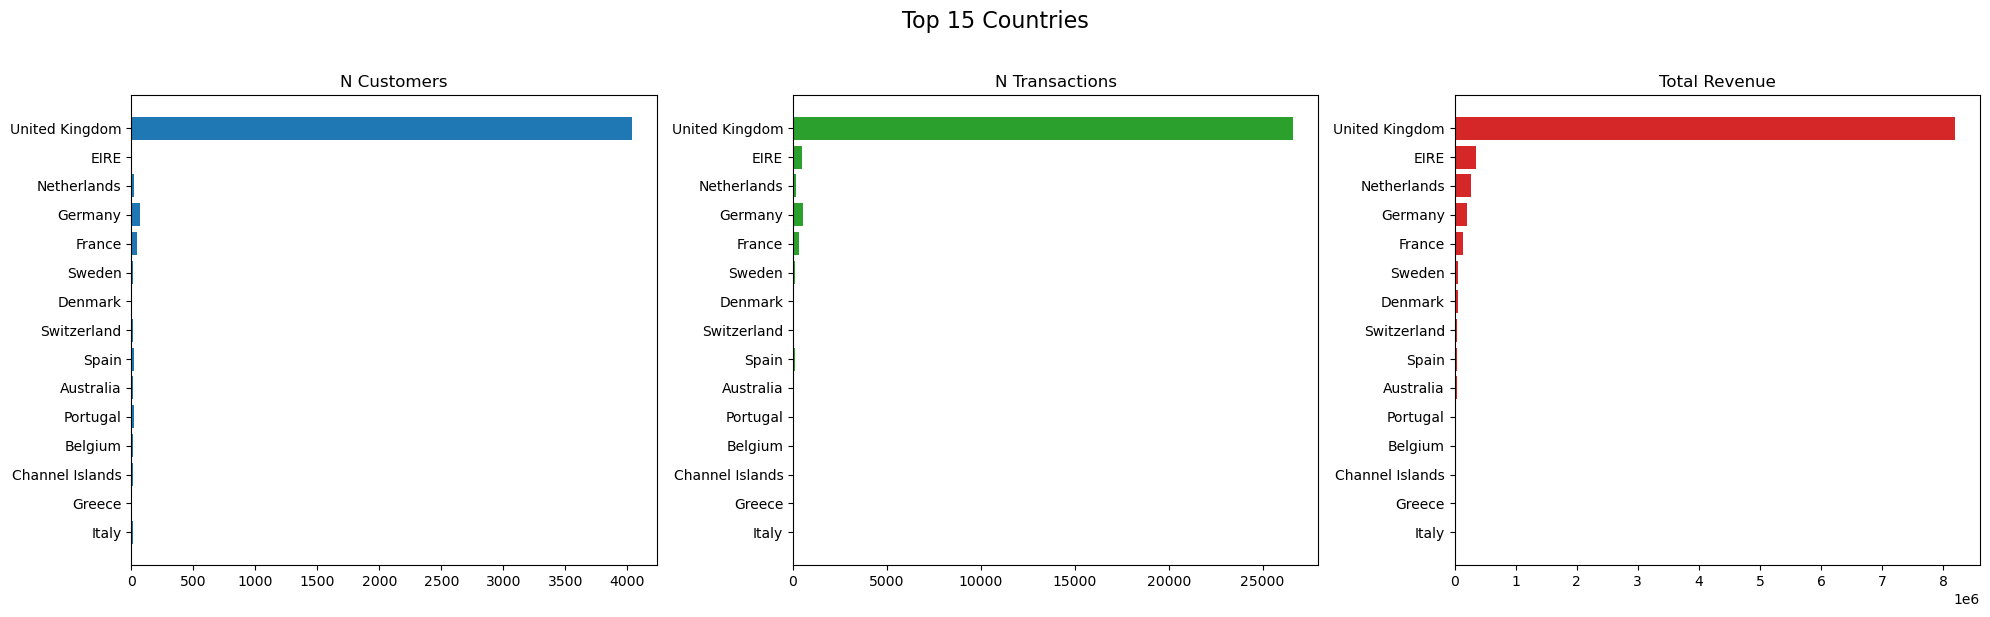

In [12]:
cls_eda.plot_top_countries()

## Cancellation Analysis

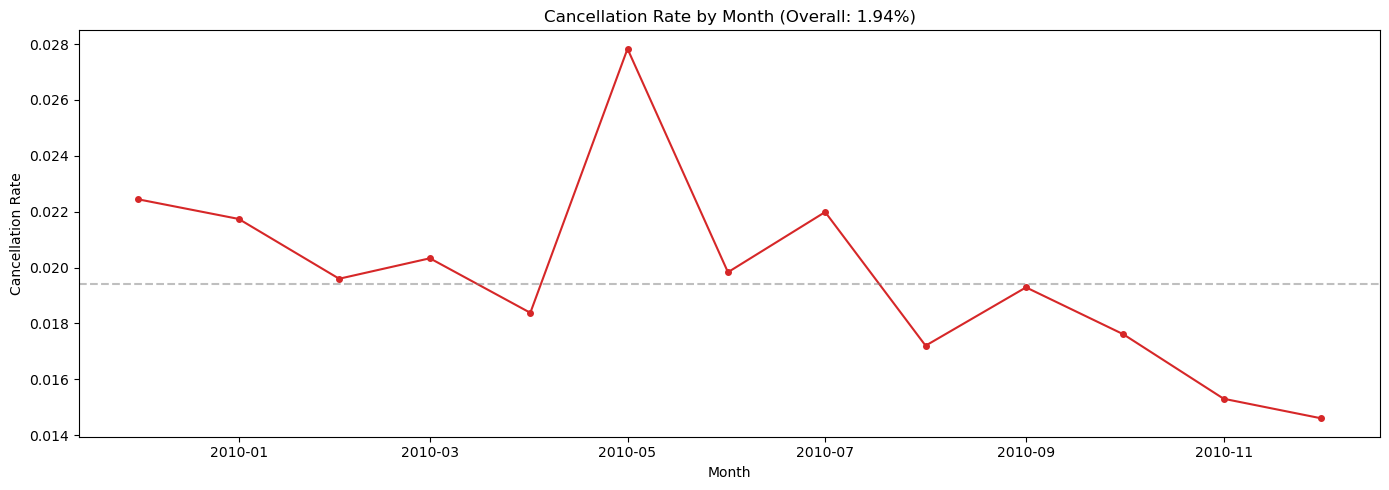

In [13]:
cls_eda.plot_cancellation_analysis()

## RFM Preview

Preview of Recency, Frequency, and Monetary distributions at the customer level. This gives us a sense of the feature space we will use for clustering.

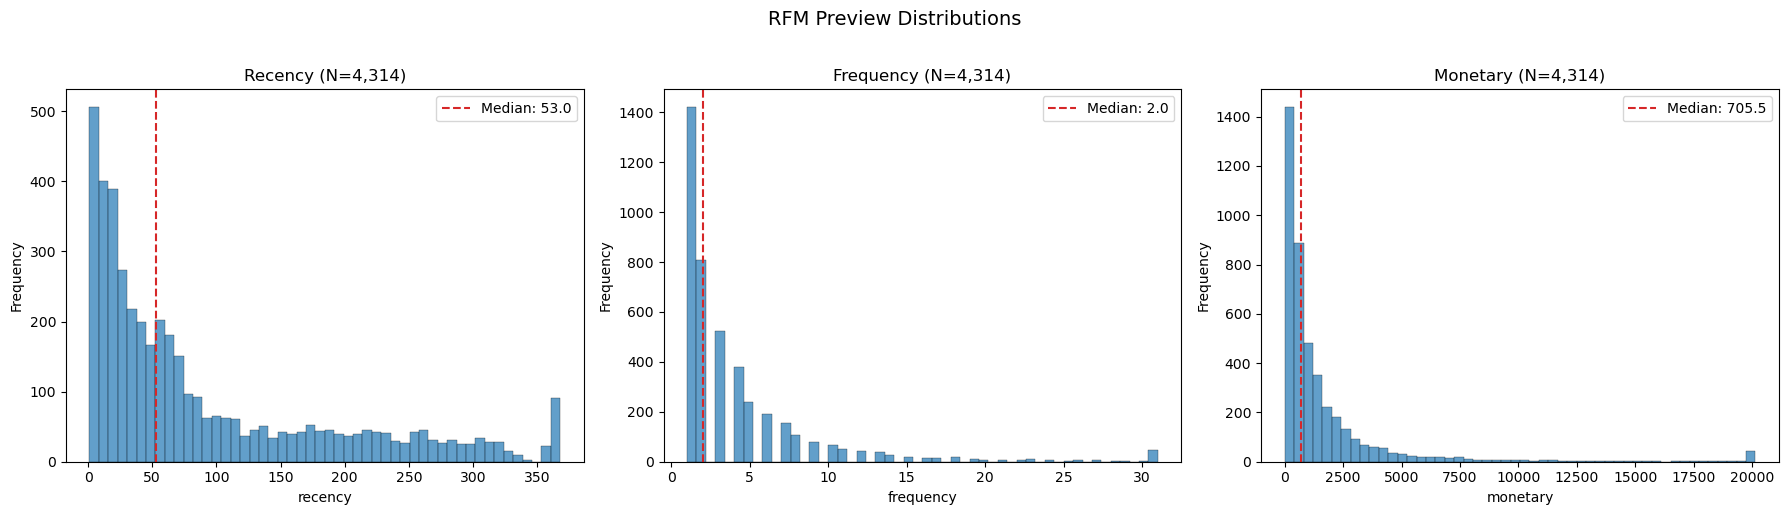

,customer_id,recency,frequency,monetary
count,4314.000000,4314.000000,4314.000000,4314.000000
mean,15348.880389,91.269124,4.454103,2047.288659
std,1700.930104,96.943482,8.168658,8912.523243
min,12346.000000,1.000000,1.000000,0.000000
25%,13883.250000,18.000000,1.000000,307.950000
50%,15348.500000,53.000000,2.000000,705.550000
75%,16833.750000,136.000000,5.000000,1722.802500
max,18287.000000,374.000000,205.000000,349164.350000


In [14]:
cls_eda.preview_rfm()
cls_eda.df_rfm_preview.describe()

## RFM Correlation Heatmap

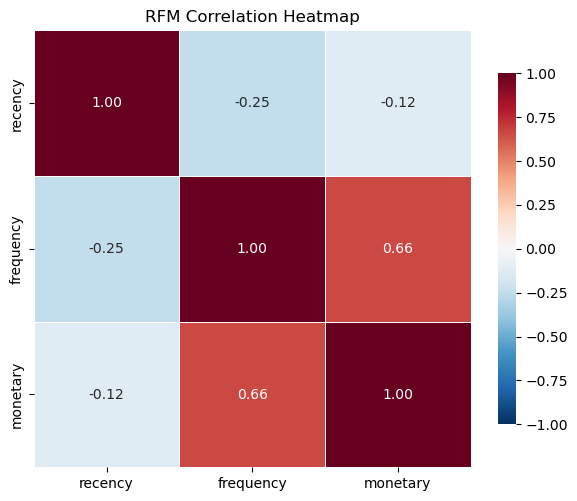

In [15]:
cls_eda.plot_correlation_heatmap()